# Use `Backtest_by_County_wsize7_atleast_20`

In [1]:
import copy
import collections
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import pyfinance
import statsmodels.formula.api as smf
import statsmodels.api as sm


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection._split import TimeSeriesSplit, _BaseKFold, indexable, _num_samples

from sklearn.utils import indexable
from sklearn.utils.validation import _num_samples, _deprecate_positional_args

from statsmodels.regression.rolling import RollingOLS
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

In [2]:
OVERWRITE = False

DATA_FOLDER = "../data"
FIGURES_FOLDER = "../figures"
OUTPUT_FOLDER = "../output"
CASE_COUNTS_FOLDER = os.path.join(DATA_FOLDER,"block_windowsize=2")
CASE_COUNTS_FNAMES_ARRAY = os.listdir(CASE_COUNTS_FOLDER)

COMPARISON_FOLDER = os.path.join(DATA_FOLDER,"confusion_state_forests_windowsize=2")
COMPARISON_FOLDER_FNAMES_ARRAY = os.listdir(COMPARISON_FOLDER)

BACKTEST_FOLDER = os.path.join(DATA_FOLDER,"Backtest_by_County_wsize7_atleast_20")
BACKTEST_FOLDER_FNAMES_ARRAY = os.listdir(BACKTEST_FOLDER)

HTE_GRF_FOLDER = os.path.join(DATA_FOLDER,"HTE_state_forests_windowsize=2")
HTE_GRF_FOLDER_FNAMES_ARRAY = os.listdir(HTE_GRF_FOLDER)

HTE_GRF_2BLOCK_FOLDER = os.path.join(DATA_FOLDER,"HTE_state_forests_windowsize=2_2BLOCK")
HTE_GRF_2BLOCK_FOLDER_FNAMES_ARRAY = os.listdir(HTE_GRF_2BLOCK_FOLDER)

In [3]:
sample_df = pd.read_csv(os.path.join(CASE_COUNTS_FOLDER,CASE_COUNTS_FNAMES_ARRAY[0]))
to_keep = ["fips", "datetime", "log_rolled_cases.x", "log_rolled_cases.y", "cutoff", "t0.lm", "r.lm", "shifted_log_rolled_cases"]
sample_df.columns


Index(['fips', 'State_FIPS_Code', 'county', 'state', 'datetime',
       'log_rolled_cases.x', 'shifted_time', 'log_rolled_cases.y', 'LAT',
       'LON',
       ...
       'totalTestsPeopleViralIncrease', 'totalTestsViral',
       'totalTestsViralIncrease', 'metrics.testPositivityRatio',
       'metrics.vaccinationsInitiatedRatio',
       'metrics.vaccinationsCompletedRatio', 'cutoff', 't0.lm', 'r.lm',
       'shifted_log_rolled_cases'],
      dtype='object', length=422)

### Analyze on `all_backtest_latest.csv`

In [4]:
all_backtest_fname = os.path.join(DATA_FOLDER,"wsize7_atleast_20_backup","all_backtest_latest.csv")
if (not os.path.isfile(all_backtest_fname) or OVERWRITE):
    print("{} not yet generated".format(all_backtest_fname))

    # Get the backtest fnames for all states
    BACKTEST_PATH_ARRAY = [os.path.join(BACKTEST_FOLDER,fname) for fname in BACKTEST_FOLDER_FNAMES_ARRAY]
    all_backtest_df_orig = pd.concat(map(pd.read_csv, BACKTEST_PATH_ARRAY))
    # Drop columns
    dropcols = ['D.r.lm', 'D.tau.hat', 'B.D.r.lm','B.D.tau.hat']
    dropcols += ['predicted.grf.future.0', "state"]
    #dropcols += ["D.r.slm","B.D.r.slm"]
    all_backtest_df = all_backtest_df_orig.drop(columns=dropcols,axis=1)
    # Rename tau.hat to r.grf
    renamecols = {"tau.hat":"r.grf", "predicted.grf.future.last":"predicted.grf"}
    all_backtest_df = all_backtest_df.rename(columns=renamecols)
    all_backtest_df.to_csv(all_backtest_fname, index=False)

else:
    print("Loading {}".format(all_backtest_fname))
    all_backtest_df = pd.read_csv(all_backtest_fname)

Loading ../data\wsize7_atleast_20_backup\all_backtest_latest.csv


In [5]:
all_backtest_df = all_backtest_df.dropna()
all_backtest_df.head(12)

,fips,county,r.lm,predicted.lm,r.slm,predicted.slm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,predicted.grf,D.r.slm,B.D.r.slm,lm.pred.2,lm.pred.3,lm.pred.4,lm.pred.5,lm.pred.6,lm.pred.7,lm.pred.8,lm.pred.9,lm.pred.10,lm.pred.11,lm.pred.12,lm.pred.13,lm.pred.14
13,10001,Kent,0.102975,6.252521,0.102975,6.252521,2020-04-21,91,5.941298,0.095898,6.202979,0.000745,1.0,6.242074,6.264213,6.273306,6.303312,6.330502,6.350305,6.371313,6.408963,6.449585,6.506351,6.574202,6.650467,6.738077
14,10001,Kent,0.073057,6.116150,0.073057,6.116150,2020-04-22,92,5.990393,0.072813,6.114442,-0.029918,-1.0,6.334051,6.311588,6.316082,6.320727,6.342994,6.366486,6.385693,6.406401,6.441597,6.480391,6.534140,6.598842,6.672231
15,10001,Kent,0.064637,6.121848,0.064637,6.121848,2020-04-23,93,6.046020,0.064163,6.118531,-0.008420,-1.0,6.435415,6.411458,6.387349,6.381981,6.380847,6.395590,6.414083,6.430793,6.449675,6.481724,6.517966,6.568315,6.629536
16,10001,Kent,0.066262,6.199484,0.066262,6.199484,2020-04-24,94,6.095503,0.063536,6.180406,0.001625,1.0,6.441879,6.464413,6.458808,6.443469,6.437831,6.435462,6.446275,6.461528,6.476343,6.493672,6.523046,6.556961,6.604220
17,10001,Kent,0.064740,6.253573,0.064740,6.253573,2020-04-25,95,6.136183,0.063347,6.243817,-0.001522,-1.0,6.420946,6.453220,6.480851,6.487271,6.481420,6.479451,6.478881,6.488713,6.502709,6.516807,6.533419,6.561000,6.593220
18,10001,Kent,0.048934,6.191865,0.048934,6.191865,2020-04-26,96,6.185915,0.051172,6.207531,-0.015806,-1.0,6.534035,6.500848,6.507214,6.523889,6.530011,6.526817,6.525825,6.525692,6.534257,6.546824,6.559932,6.575594,6.601377
19,10001,Kent,0.049006,6.241371,0.049006,6.241371,2020-04-27,97,6.232167,0.051136,6.256281,0.000072,1.0,6.555936,6.568692,6.553208,6.555593,6.567442,6.573145,6.571575,6.571332,6.571617,6.579306,6.590770,6.603050,6.617876
20,10001,Kent,0.042968,6.242074,0.042968,6.242074,2020-04-28,98,6.278253,0.046327,6.265585,-0.006038,-1.0,6.600856,6.601467,6.609723,6.600941,6.602296,6.611451,6.616707,6.616150,6.616443,6.617069,6.624101,6.634676,6.646240
21,10001,Kent,0.049094,6.334051,0.049094,6.334051,2020-04-29,99,6.311735,0.045765,6.310746,0.006126,1.0,6.546105,6.592322,6.612032,6.627949,6.628324,6.633193,6.643307,6.650080,6.651631,6.653435,6.655224,6.662467,6.672904
22,10001,Kent,0.055628,6.435415,0.055628,6.435415,2020-04-30,100,6.327171,0.054530,6.427733,0.006534,1.0,6.435226,6.501391,6.558051,6.592921,6.619398,6.630435,6.641828,6.655869,6.666259,6.671423,6.676086,6.680213,6.688822


In [6]:
lm_rmse = all_backtest_df.groupby(["days_from_start.y"]).apply(lambda x: mean_squared_error(x["predicted.lm"], x["log_rolled_cases.y"]) ** .5)
grf_rmse = all_backtest_df.groupby(["days_from_start.y"]).apply(lambda x: mean_squared_error(x["predicted.grf"], x["log_rolled_cases.y"]) ** .5)

(0.08, 1.0)

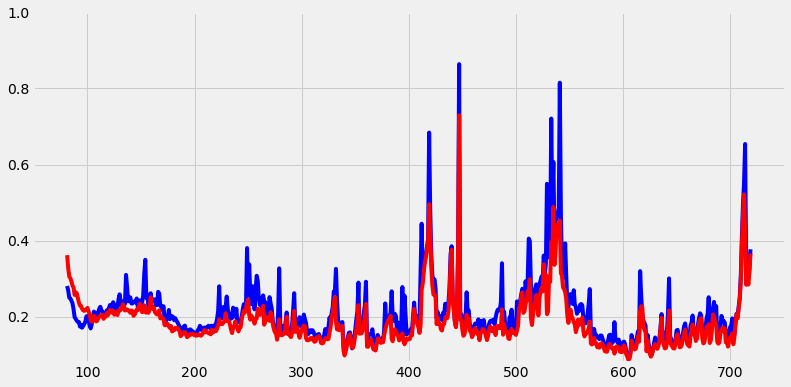

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lm_rmse, color="blue", label="lm wsize=2")
ax.plot(grf_rmse, color = "red", label="grf")
plt.ylim([0.08,1.0])
#plt.xlim([365,len(grf_rmse)])

In [8]:
historical_data = all_backtest_df[["fips","days_from_start.y","log_rolled_cases.y"]]
historical_data['date_delta'] = (historical_data['days_from_start.y'] - historical_data['days_from_start.y'].min()) 

historical_data.head()

,fips,days_from_start.y,log_rolled_cases.y,date_delta
13,10001,91,5.941298,10
14,10001,92,5.990393,11
15,10001,93,6.046020,12
16,10001,94,6.095503,13
17,10001,95,6.136183,14


In [9]:
model_dict_fname = os.path.join(DATA_FOLDER,"model_dict.p")
OVERWRITE = False
if (not os.path.isfile(model_dict_fname)) or OVERWRITE:
    print("Generating model parameters and writing to {}".format(model_dict_fname))
    X = historical_data["date_delta"]
    X = sm.add_constant(X)
    y = historical_data["days_from_start.y"]
    model_dict = collections.defaultdict(dict)
    for wsize in range(2, 15):
        all_backtest_df["lm.pred.{}".format(wsize)] = np.nan
        for fips in tqdm(historical_data["fips"].unique()):
            df_mask = historical_data["fips"]==fips
            df = historical_data[df_mask]
            if df.shape[0] < wsize + 1:
                continue
            endog = df[['log_rolled_cases.y']].values
            exog = (df['days_from_start.y'] - df['days_from_start.y'].min()).values
            exog = sm.add_constant(exog)
            model = RollingOLS(endog=endog, exog=exog, window=wsize)
            results = model.fit()
            model_dict[wsize][fips] = results.params
            ypred = results.params[:,0] + results.params[:,1]*np.array([7 + i for i in range(len(endog))])
            all_backtest_df.loc[df_mask,'lm.pred.{}'.format(wsize)] = ypred
    with open(model_dict_fname, "wb+") as f:
        pickle.dump(model_dict,f)
    all_backtest_df.to_csv(all_backtest_fname, index=False)
else:
    print("Loading existing {}".format(model_dict_fname))
    with open(model_dict_fname, "rb+") as f:
        model_dict = pickle.load(f)
    all_backtest_df = pd.read_csv(all_backtest_fname)

Loading existing ../data\model_dict.p


In [10]:
preds = all_backtest_df[["fips","days_from_start.y"]+list(all_backtest_df.columns[12:])]
preds["days_from_start.y"] += 7
all_backtest_df_old = all_backtest_df[all_backtest_df.columns[:12]]
all_backtest_df.columns

Index(['fips', 'county', 'r.lm', 'predicted.lm', 'r.slm', 'predicted.slm',
       'date.y', 'days_from_start.y', 'log_rolled_cases.y', 'r.grf',
       'predicted.grf', 'D.r.slm', 'B.D.r.slm', 'lm.pred.2', 'lm.pred.3',
       'lm.pred.4', 'lm.pred.5', 'lm.pred.6', 'lm.pred.7', 'lm.pred.8',
       'lm.pred.9', 'lm.pred.10', 'lm.pred.11', 'lm.pred.12', 'lm.pred.13',
       'lm.pred.14'],
      dtype='object')

In [11]:
adjusted = pd.merge(left=all_backtest_df_old, right=preds.shift(7), left_on=["fips","days_from_start.y"], right_on=["fips","days_from_start.y"], how="left")
adjusted = adjusted.dropna()

###  `augmented_us-counties_latest.csv`

In [12]:
augmented_fname = os.path.join(DATA_FOLDER,"augmented_us-counties_latest.csv")
county_historical_data_fname = os.path.join(DATA_FOLDER,"county_historical_data.csv")
if (not os.path.isfile(county_historical_data_fname) or OVERWRITE):
    augmented = pd.read_csv(augmented_fname)
    cols_to_keep = ["fips","date","days_from_start","county","state","log_rolled_cases"]
    county_historical_data = augmented.sort_values(["fips","date"])
    county_historical_data = county_historical_data[county_historical_data["rolled_cases"] >= 20]
    county_historical_data["log_rolled_cases"] = np.log(county_historical_data["rolled_cases"])
    county_historical_data = county_historical_data[cols_to_keep]

    # Get rid of records with less than 2 entries
    v = county_historical_data[['fips']]
    county_historical_data[v.replace(v.stack().value_counts()).gt(2).all(1)]


    county_historical_data.to_csv(county_historical_data_fname, index=False)
else:
    county_historical_data = pd.read_csv(county_historical_data_fname)

In [13]:
model_dict_county_fname = os.path.join(DATA_FOLDER,"model_dict_county.p")
county_historical_data_rolling_fname = os.path.join(DATA_FOLDER,"county_historical_data_rolling.csv")
county_historical_data_rolling = county_historical_data.copy()
if (not os.path.isfile(model_dict_county_fname)) or OVERWRITE:
    print("Generating model parameters and writing to {}".format(model_dict_county_fname))
    model_dict_county = collections.defaultdict(dict)
    for wsize in range(2, 15):
        county_historical_data_rolling["lm.pred.{}".format(wsize)] = np.nan
        for fips in tqdm(county_historical_data_rolling["fips"].unique()):
            df_mask = county_historical_data_rolling["fips"]==fips
            df = county_historical_data_rolling[df_mask]
            if df.shape[0] < wsize + 1:
                continue
            endog = df[['log_rolled_cases']]
            exog = (df['days_from_start'] - df['days_from_start'].min())
            exog = sm.add_constant(exog)
            model = RollingOLS(endog=endog, exog=exog, window=wsize)
            results = model.fit(params_only=True)
            model_dict_county[wsize][fips] = results.params
            par = results.params.values
            ypred = endog.values.flatten() + par[:,1]*np.array([7 for i in range(len(endog))])
            county_historical_data_rolling.loc[df_mask,'lm.pred.{}'.format(wsize)] = ypred
            #break
    
    with open(model_dict_county_fname, "wb+") as f:
        pickle.dump(model_dict_county,f)
    county_historical_data_rolling.to_csv(county_historical_data_rolling_fname, index=False)
else:
    print("Loading existing {}".format(model_dict_county_fname))
    with open(model_dict_county_fname, "rb+") as f:
        model_dict_county = pickle.load(f)
    county_historical_data_rolling = pd.read_csv(county_historical_data_rolling_fname)

Loading existing ../data\model_dict_county.p


In [14]:
county_historical_data_rolling.loc[county_historical_data_rolling["fips"]==10001]

,fips,date,days_from_start,county,state,log_rolled_cases,lm.pred.2,lm.pred.3,lm.pred.4,lm.pred.5,lm.pred.6,lm.pred.7,lm.pred.8,lm.pred.9,lm.pred.10,lm.pred.11,lm.pred.12,lm.pred.13,lm.pred.14
127379,10001,2020-03-29,68,Kent,Delaware,3.113515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127380,10001,2020-03-30,69,Kent,Delaware,3.198673,3.794778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127381,10001,2020-03-31,70,Kent,Delaware,3.323236,4.195175,4.057258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127382,10001,2020-04-01,71,Kent,Delaware,3.457893,4.400491,4.365161,4.268279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127383,10001,2020-04-02,72,Kent,Delaware,3.590439,4.518266,4.525652,4.507408,4.439587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127912,10001,2021-09-13,601,Kent,Delaware,7.607754,7.650466,7.655439,7.660213,7.662995,7.656539,7.646703,7.641524,7.640944,7.648139,7.661040,7.673845,7.685806,7.693808
127913,10001,2021-09-14,602,Kent,Delaware,7.608002,7.609740,7.630227,7.641406,7.649349,7.654511,7.651852,7.645298,7.641486,7.641063,7.647081,7.658198,7.669615,7.680578
127914,10001,2021-09-15,603,Kent,Delaware,7.611224,7.633777,7.623369,7.631499,7.639601,7.646711,7.652047,7.651243,7.646766,7.643966,7.643737,7.648913,7.658640,7.668906
127915,10001,2021-09-16,604,Kent,Delaware,7.619724,7.679226,7.660751,7.647117,7.647454,7.651112,7.655691,7.659735,7.659254,7.655680,7.653278,7.652959,7.657293,7.665739


In [15]:
all_backtest_df_old

,fips,county,r.lm,predicted.lm,r.slm,predicted.slm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,predicted.grf,D.r.slm
0,10001,Kent,0.151550,4.372435,0.151550,4.372435,2020-04-08,78,4.643016,0.172123,4.516447,-0.005636
1,10001,Kent,0.117783,4.253850,0.117783,4.253850,2020-04-09,79,4.850914,0.145401,4.447177,-0.033767
2,10001,Kent,0.142174,4.566764,0.142174,4.566764,2020-04-10,80,5.026696,0.160216,4.693052,0.024391
3,10001,Kent,0.159301,4.845950,0.159301,4.845950,2020-04-11,81,5.184989,0.161397,4.860620,0.017126
4,10001,Kent,0.189714,5.248558,0.189714,5.248558,2020-04-12,82,5.326488,0.173349,5.134002,0.030413
...,...,...,...,...,...,...,...,...,...,...,...,...
1474425,99999,New York City,0.120853,13.072759,0.120853,13.072759,2022-01-05,715,12.995033,0.108311,12.984966,-0.003061
1474426,99999,New York City,0.121970,13.202545,0.121970,13.202545,2022-01-06,716,13.073238,0.106001,13.090768,0.001117
1474427,99999,New York City,0.124747,13.346731,0.124747,13.346731,2022-01-07,717,13.144309,0.100522,13.177158,0.002777
1474428,99999,New York City,0.132440,13.533026,0.132440,13.533026,2022-01-08,718,13.209524,0.116362,13.420481,0.007694


In [16]:
county_historical_data_rolling.columns

Index(['fips', 'date', 'days_from_start', 'county', 'state',
       'log_rolled_cases', 'lm.pred.2', 'lm.pred.3', 'lm.pred.4', 'lm.pred.5',
       'lm.pred.6', 'lm.pred.7', 'lm.pred.8', 'lm.pred.9', 'lm.pred.10',
       'lm.pred.11', 'lm.pred.12', 'lm.pred.13', 'lm.pred.14'],
      dtype='object')

### Add HTE GRF

In [17]:
HTE_GRF_FOLDER_PATHS_ARRAY = [os.path.join(HTE_GRF_FOLDER,fname) for fname in HTE_GRF_FOLDER_FNAMES_ARRAY]
HTE_grf_df_orig = pd.concat(map(pd.read_csv, HTE_GRF_FOLDER_PATHS_ARRAY))
# We just need the FIPS, days_from_start, datetime, and predicted.grf.future to combine with `adjusted`
HTE_cols = ["fips","days_from_start","predicted.grf.future"]
HTE_predictions = HTE_grf_df_orig[HTE_cols]
HTE_predictions["predicted.grf.HTE"] = HTE_predictions["predicted.grf.future"]
HTE_predictions = HTE_predictions.drop(columns=["predicted.grf.future"],axis=1)
HTE_predictions

,fips,days_from_start,predicted.grf.HTE
0,1001,100,3.702180
1,1003,100,4.924521
2,1005,100,3.804257
3,1007,100,3.721491
4,1009,100,3.302386
...,...,...,...
1199,56021,99,4.555457
1200,56025,99,2.934049
1201,56039,99,3.827718
1202,78030,99,3.032455


In [18]:
HTE_GRF_2BLOCK_FOLDER_PATHS_ARRAY = [os.path.join(HTE_GRF_2BLOCK_FOLDER,fname) for fname in HTE_GRF_2BLOCK_FOLDER_FNAMES_ARRAY]
HTE_2BLOCK_grf_df_orig = pd.concat(map(pd.read_csv, HTE_GRF_2BLOCK_FOLDER_PATHS_ARRAY))
# We just need the FIPS, days_from_start, datetime, and predicted.grf.future to combine with `adjusted`
HTE_2BLOCK_cols = ["fips","days_from_start","predicted.grf.future"]
HTE_2BLOCK_predictions = HTE_2BLOCK_grf_df_orig[HTE_2BLOCK_cols]
HTE_2BLOCK_predictions["predicted.grf.HTE_2BLOCK"] = HTE_2BLOCK_predictions["predicted.grf.future"]
HTE_2BLOCK_predictions = HTE_2BLOCK_predictions.drop(columns=["predicted.grf.future"],axis=1)
HTE_2BLOCK_predictions

,fips,days_from_start,predicted.grf.HTE_2BLOCK
0,1001,100,3.658196
1,1003,100,4.937272
2,1005,100,3.896896
3,1007,100,3.753570
4,1009,100,3.342496
...,...,...,...
1199,56021,99,4.519407
1200,56025,99,2.876919
1201,56039,99,3.788702
1202,78030,99,2.949920


In [19]:
HTE_predictions[HTE_predictions["fips"]==10001].sort_values(by=["fips","days_from_start"])

,fips,days_from_start,predicted.grf.HTE
62,10001,70,5.178153
67,10001,71,5.227260
69,10001,72,5.119017
73,10001,73,5.350309
81,10001,74,5.625684
...,...,...,...
290,10001,715,9.259354
292,10001,716,9.298801
292,10001,717,9.324306
295,10001,718,9.391178


In [20]:
grf_historical = all_backtest_df_old[["fips","days_from_start.y","predicted.grf"]]
grf_historical = grf_historical.rename(columns={"days_from_start.y":"days_from_start"})
preds = county_historical_data_rolling[["fips","days_from_start"]+list(county_historical_data_rolling.columns[6:])]
preds["days_from_start"] += 7
county_historical_data_rolling_old = county_historical_data_rolling[county_historical_data_rolling.columns[:6]]
adjusted = pd.merge(left=county_historical_data_rolling_old, right=preds.shift(7), left_on=["fips","days_from_start"], right_on=["fips","days_from_start"], how="left")
adjusted = pd.merge(left=grf_historical, right=adjusted, left_on=["fips","days_from_start"], right_on=["fips","days_from_start"], how="left")

adjusted = pd.merge(left=adjusted, right=HTE_predictions, left_on=["fips","days_from_start"], right_on=["fips","days_from_start"], how="left")
adjusted = pd.merge(left=adjusted, right=HTE_2BLOCK_predictions, left_on=["fips","days_from_start"], right_on=["fips","days_from_start"], how="left")

adjusted = adjusted.dropna()

In [21]:
adjusted[adjusted["predicted.grf.HTE"].isna()]

,fips,days_from_start,predicted.grf,date,county,state,log_rolled_cases,lm.pred.2,lm.pred.3,lm.pred.4,lm.pred.5,lm.pred.6,lm.pred.7,lm.pred.8,lm.pred.9,lm.pred.10,lm.pred.11,lm.pred.12,lm.pred.13,lm.pred.14,predicted.grf.HTE,predicted.grf.HTE_2BLOCK


## Fixed Window Sizes for All Counties

In [22]:
error_table = pd.DataFrame()
error_table["grf.rmse"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_squared_error( (x["predicted.grf"]),  (x["log_rolled_cases"])) ** .5)
error_table["grf.mape"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_percentage_error( (x["log_rolled_cases"]), (x["predicted.grf"])) )
error_table["grf.mae"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error( (x["predicted.grf"]),  (x["log_rolled_cases"])) )

error_table["grf.HTE.rmse"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_squared_error( (x["predicted.grf.HTE"]),  (x["log_rolled_cases"])) ** .5)
error_table["grf.HTE.mape"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_percentage_error( (x["log_rolled_cases"]), (x["predicted.grf.HTE"])) )
error_table["grf.HTE.mae"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error( (x["predicted.grf.HTE"]),  (x["log_rolled_cases"])) )

error_table["grf.HTE_2BLOCK.rmse"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_squared_error( (x["predicted.grf.HTE_2BLOCK"]),  (x["log_rolled_cases"])) ** .5)
error_table["grf.HTE_2BLOCK.mape"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_percentage_error( (x["log_rolled_cases"]), (x["predicted.grf.HTE_2BLOCK"])) )
error_table["grf.HTE_2BLOCK.mae"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error( (x["predicted.grf.HTE_2BLOCK"]),  (x["log_rolled_cases"])) )


for wsize in tqdm(range(2,14+1)):
    error_table["lm.rmse.{}".format(wsize)]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_squared_error((x["lm.pred.{}".format(wsize)]), (x["log_rolled_cases"])) ** .5)
    error_table["lm.mae.{}".format(wsize)]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error((x["lm.pred.{}".format(wsize)]), (x["log_rolled_cases"])) )
    error_table["lm.mape.{}".format(wsize)]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_percentage_error((x["log_rolled_cases"]),(x["lm.pred.{}".format(wsize)])) )

error_table["date"] = sorted(adjusted["date"].unique())
#error_table = error_table.reset_index()
#error_table = error_table.set_index(adjusted["date.y"])
error_table.to_csv(os.path.join(DATA_FOLDER,"error_table_by_time.csv"))

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:16<00:00,  1.30s/it]


In [23]:
adjusted.groupby("days_from_start").apply(lambda x: mean_squared_error(x["predicted.grf"], x["log_rolled_cases"]) ** .5)

days_from_start
68     0.343382
69     0.530445
70     0.509443
71     0.462300
72     0.418171
         ...   
601    0.146892
602    0.138999
603    0.120543
604    0.120761
605    0.118117
Length: 538, dtype: float64

In [24]:
error_table.columns
mape_columns = ["grf.mape"] + ["grf.HTE.mape"] + ["lm.mape.{}".format(wsize) for wsize in range(2,14+1)]
rmse_columns = ["grf.rmse"] + ["grf.HTE.rmse"] + ["lm.rmse.{}".format(wsize) for wsize in range(2,14+1)]
date_column = ["days_from_start"]

In [25]:
error_table

,grf.rmse,grf.mape,grf.mae,grf.HTE.rmse,grf.HTE.mape,grf.HTE.mae,grf.HTE_2BLOCK.rmse,grf.HTE_2BLOCK.mape,grf.HTE_2BLOCK.mae,lm.rmse.2,lm.mae.2,lm.mape.2,lm.rmse.3,lm.mae.3,lm.mape.3,lm.rmse.4,lm.mae.4,lm.mape.4,lm.rmse.5,lm.mae.5,lm.mape.5,lm.rmse.6,lm.mae.6,lm.mape.6,lm.rmse.7,lm.mae.7,lm.mape.7,lm.rmse.8,lm.mae.8,lm.mape.8,lm.rmse.9,lm.mae.9,lm.mape.9,lm.rmse.10,lm.mae.10,lm.mape.10,lm.rmse.11,lm.mae.11,lm.mape.11,lm.rmse.12,lm.mae.12,lm.mape.12,lm.rmse.13,lm.mae.13,lm.mape.13,lm.rmse.14,lm.mae.14,lm.mape.14,date
days_from_start,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
68,0.343382,0.044434,0.327011,1.881871,0.258156,1.880870,1.958341,0.266145,1.952761,0.230322,0.190962,0.024388,0.243484,0.206519,0.026394,0.295962,0.222895,0.027372,0.344564,0.264010,0.032745,0.349023,0.258750,0.032052,0.330619,0.258021,0.032686,0.273025,0.235071,0.030839,0.238324,0.218734,0.029988,0.238218,0.209546,0.029922,0.268791,0.218738,0.031995,0.314490,0.277781,0.039676,0.357450,0.327378,0.046004,0.402777,0.371838,0.051830,2020-03-29
69,0.530445,0.055269,0.472175,1.705479,0.217728,1.705297,1.943809,0.246619,1.942013,0.664242,0.462440,0.049177,0.712989,0.494627,0.052694,0.790634,0.533133,0.056468,0.911373,0.598589,0.062763,0.998667,0.653985,0.068546,1.026359,0.675609,0.071155,0.993004,0.664372,0.070615,0.936851,0.632989,0.067930,0.889120,0.607330,0.066012,0.869650,0.596223,0.065561,0.866638,0.596368,0.066357,0.875141,0.605239,0.068101,0.878579,0.609833,0.069234,2020-03-30
70,0.509443,0.053805,0.450533,1.635177,0.210322,1.625103,1.921459,0.246513,1.907240,0.536802,0.402215,0.045992,0.631052,0.459754,0.051388,0.690651,0.504397,0.056074,0.757685,0.548713,0.060734,0.856686,0.604432,0.066307,0.940036,0.658407,0.072132,0.981829,0.691373,0.076064,0.976549,0.700372,0.077730,0.945979,0.690012,0.077283,0.914638,0.678322,0.076722,0.900534,0.675098,0.077013,0.893527,0.673122,0.077255,0.892783,0.672800,0.077533,2020-03-31
71,0.462300,0.046047,0.389129,1.574616,0.204240,1.568586,1.713408,0.222022,1.702679,0.479911,0.344680,0.039545,0.539047,0.385217,0.044524,0.648953,0.454425,0.052439,0.765483,0.549837,0.064029,0.870616,0.619212,0.071669,0.976325,0.675842,0.077248,1.044819,0.718567,0.081419,1.061146,0.741275,0.083847,1.042134,0.745073,0.084494,1.005136,0.731705,0.083181,0.970323,0.716395,0.081672,0.949208,0.705790,0.080547,0.932723,0.693813,0.079144,2020-04-01
72,0.418171,0.040029,0.332441,1.531631,0.198015,1.521394,1.718209,0.223336,1.703308,0.552319,0.458895,0.058221,0.568949,0.458384,0.057301,0.556758,0.457823,0.056165,0.588306,0.460925,0.055032,0.666493,0.491983,0.057694,0.755616,0.533731,0.061730,0.851769,0.591975,0.067979,0.923637,0.643433,0.073621,0.956932,0.672955,0.076959,0.958232,0.689715,0.079159,0.940675,0.692559,0.079809,0.922988,0.694026,0.080347,0.912947,0.697943,0.081091,2020-04-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601,0.146892,0.020488,0.110665,0.291306,0.043581,0.247755,0.259418,0.040084,0.225636,0.188799,0.142426,0.026084,0.197577,0.144152,0.026745,0.185786,0.134187,0.024977,0.179991,0.130756,0.024274,0.179277,0.130548,0.024351,0.184094,0.135640,0.025281,0.182827,0.137079,0.025510,0.183137,0.139211,0.025809,0.181393,0.138403,0.025596,0.182163,0.138367,0.025523,0.185107,0.140869,0.025929,0.191184,0.146150,0.026845,0.195888,0.151189,0.027683,2021-09-13
602,0.138999,0.019041,0.101968,0.244949,0.036759,0.203225,0.257547,0.039032,0.216734,0.194384,0.132995,0.024583,0.172614,0.124045,0.023060,0.181879,0.130965,0.024456,0.178639,0.127364,0.023847,0.173233,0.123741,0.023165,0.171541,0.123213,0.023118,0.174197,0.126487,0.023716,0.174684,0.128839,0.024086,0.176615,0.131972,0.024580,0.177345,0.133003,0.024689,0.179341,0.134540,0.024898,0.182492,0.137537,0.025379,0.188168,0.142709,0.026262,2021-09-14
603,0.120543,0.016155,0.087175,0.241513,0.036473,0.202611,0.239501,0.035985,0.198880,0.205

### Classical GRF vs TLGRF

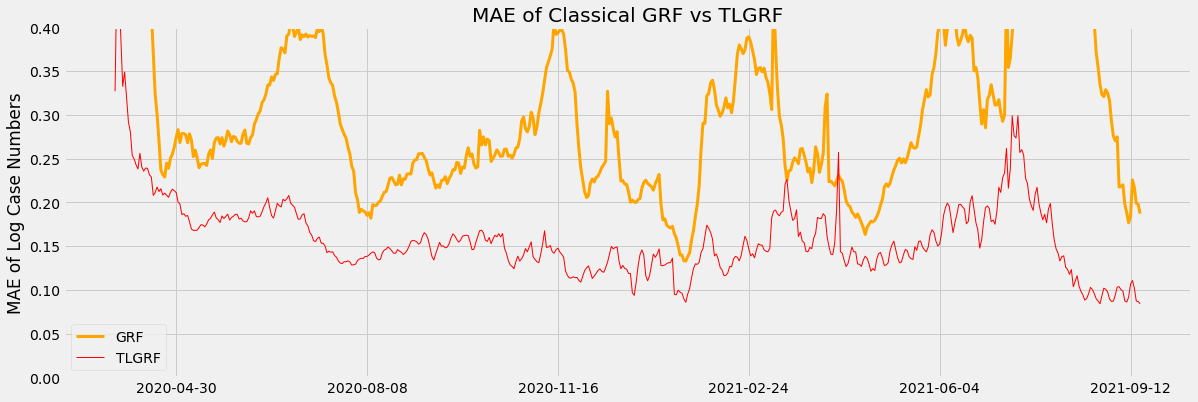

In [26]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(18, 6))
#for wsize in range(2,14+1,2):
wsizes = [2,7,14]
#colors_lm = ["blue", "xkcd:dark turquoise", "magenta"]
#linestyles_lm = ["dotted","dashed","dotted"]
my_legend = ["GRF"] + ["TLGRF"]

#ax.plot(error_table["grf.HTE.mae"], label=my_legend[-3], linewidth=1, color="blue")
ax.plot(error_table["grf.HTE_2BLOCK.mae"], label=my_legend[-2], linewidth=3, color="orange")
ax.plot(error_table["grf.mae"], label=my_legend[-1], linewidth=1, color="red")
ax.legend()

plt.ylim([0.0,0.4])
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])


plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Classical GRF vs TLGRF")
plt.savefig(os.path.join(FIGURES_FOLDER,"grf_tlgrf_mae.png"))

### Fixed Windows vs TLGRF

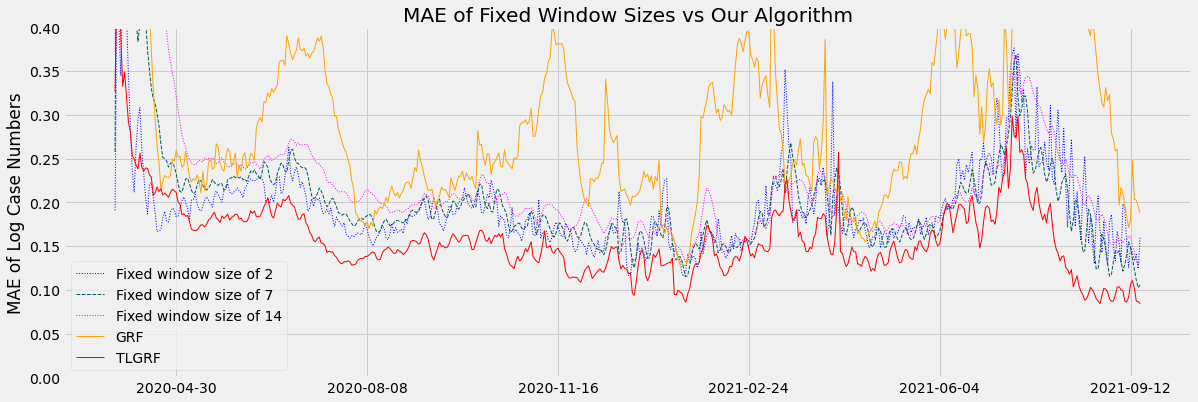

In [27]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(18, 6))
#for wsize in range(2,14+1,2):
wsizes = [2,7,14]
colors_lm = ["blue", "xkcd:dark turquoise", "magenta"]
linestyles_lm = ["dotted","dashed","dotted"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["GRF"] + ["TLGRF"]
for i,wsize in enumerate(wsizes):
    ax.plot(error_table["lm.mae.{}".format(wsize)], linestyle=linestyles_lm[i], linewidth=1, color=colors_lm[i], label=my_legend[i])

ax.plot(error_table["grf.HTE.mae"], label=my_legend[-2], linewidth=1, color="orange")
ax.plot(error_table["grf.mae"], label=my_legend[-1], linewidth=1, color="red")
ax.legend()

plt.ylim([0.0,0.4])
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])


plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Fixed Window Sizes vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_mae.png"))

In [28]:
error_table["date"]

days_from_start
68     2020-03-29
69     2020-03-30
70     2020-03-31
71     2020-04-01
72     2020-04-02
          ...    
601    2021-09-13
602    2021-09-14
603    2021-09-15
604    2021-09-16
605    2021-09-17
Name: date, Length: 538, dtype: object

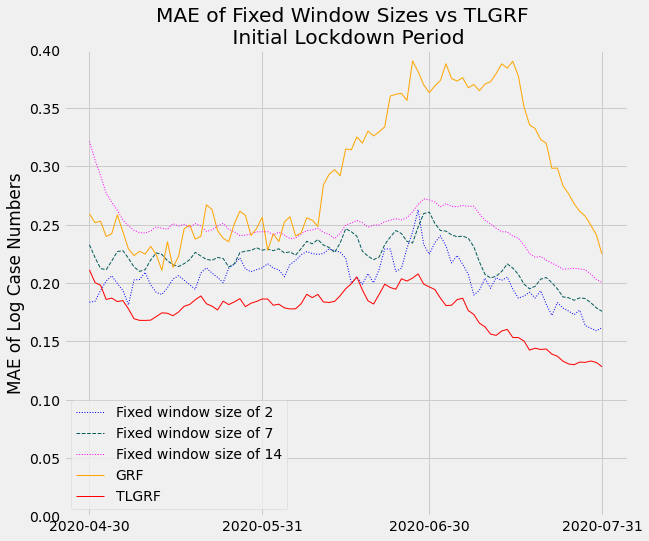

In [29]:
x_spacing = [100,131,161,192]
fig, ax = plt.subplots(figsize=(9, 8))
#for wsize in range(2,14+1,2):
wsizes = [2,7,14]
colors_lm = ["blue", "xkcd:dark turquoise", "magenta"]
linestyles_lm = ["dotted","dashed","dotted"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["GRF"] + ["TLGRF"]
for i,wsize in enumerate(wsizes):
    ax.plot(error_table.loc[100:192,"lm.mae.{}".format(wsize)], linestyle=linestyles_lm[i], linewidth=1, color=colors_lm[i], label=my_legend[i])
ax.plot(error_table.loc[100:192,"grf.HTE.mae"], label=my_legend[-2], linewidth=1, color="orange")
ax.plot(error_table.loc[100:192,"grf.mae"], label=my_legend[-1], linewidth=1, color="red")
ax.legend()

plt.ylim([0.0,0.4])
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])


plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Fixed Window Sizes vs TLGRF \n Initial Lockdown Period")
plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_mae_lockdown.png"))

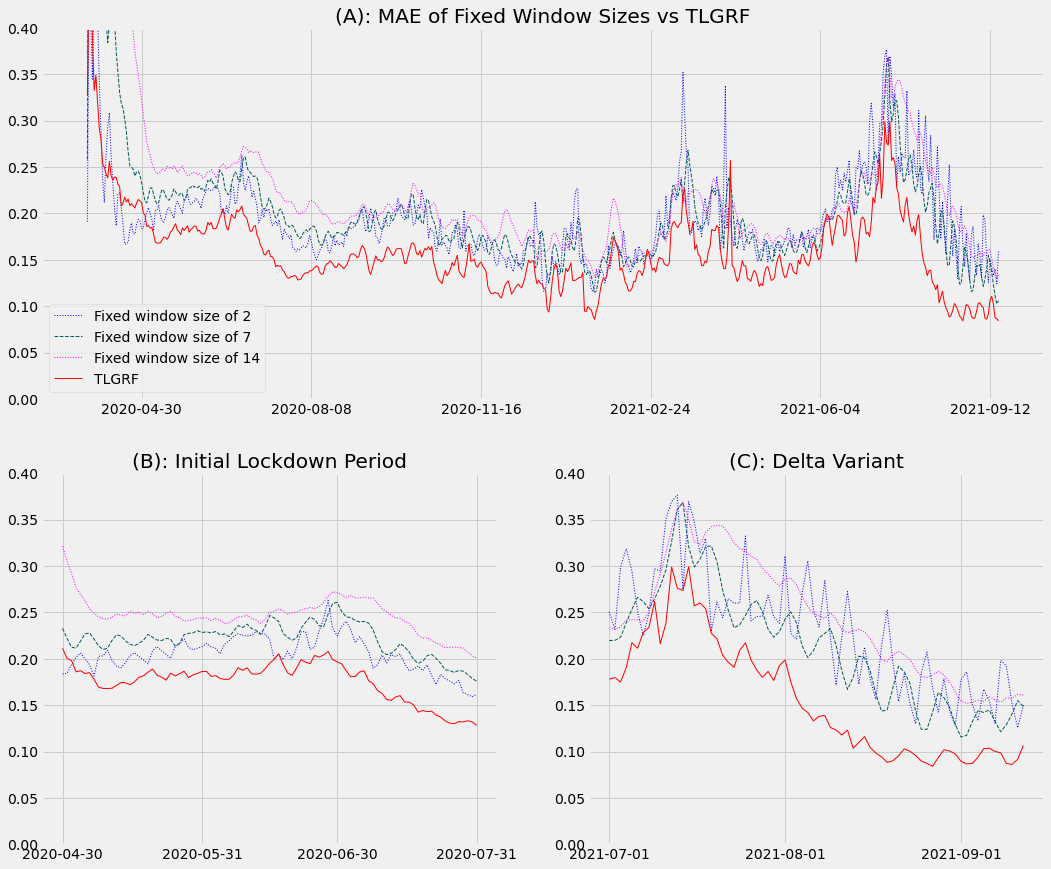

In [30]:
f = plt.figure(figsize=(16,14))

ax0 = f.add_subplot(211)
x_spacing = [100,200,300,400,500,600]
#for wsize in range(2,14+1,2):
wsizes = [2,7,14]
colors_lm = ["blue", "xkcd:dark turquoise", "magenta"]
linestyles_lm = ["dotted","dashed","dotted"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["GRF"] + ["TLGRF"]
for i,wsize in enumerate(wsizes):
    ax0.plot(error_table["lm.mae.{}".format(wsize)], linestyle=linestyles_lm[i], linewidth=1, color=colors_lm[i], label=my_legend[i])

#ax0.plot(error_table["grf.HTE.mae"], label=my_legend[-2], linewidth=1, color="orange")
ax0.plot(error_table["grf.mae"], label=my_legend[-1], linewidth=1, color="red")
ax0.title.set_text("(A): MAE of Fixed Window Sizes vs TLGRF")

plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.0,0.4])
ax0.legend()

ax1 = f.add_subplot(223)
x_spacing = [100,131,161,192]
wsizes = [2,7,14]
colors_lm = ["blue", "xkcd:dark turquoise", "magenta"]
linestyles_lm = ["dotted","dashed","dotted"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["GRF"] + ["TLGRF"]
for i,wsize in enumerate(wsizes):
    ax1.plot(error_table.loc[100:192,"lm.mae.{}".format(wsize)], linestyle=linestyles_lm[i], linewidth=1, color=colors_lm[i], label=my_legend[i])
#ax1.plot(error_table.loc[100:192,"grf.HTE.mae"], label=my_legend[-2], linewidth=1, color="orange")
ax1.plot(error_table.loc[100:192,"grf.mae"], label=my_legend[-1], linewidth=1, color="red")
ax1.title.set_text("(B): Initial Lockdown Period")
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.0,0.4])

ax2 = f.add_subplot(224)
x_spacing = [527,558,589]
#for wsize in range(2,14+1,2):
wsizes = [2,7,14]
colors_lm = ["blue", "xkcd:dark turquoise", "magenta"]
linestyles_lm = ["dotted","dashed","dotted"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["GRF"] + ["TLGRF"]
for i,wsize in enumerate(wsizes):
    ax2.plot(error_table.loc[527:600,"lm.mae.{}".format(wsize)], linestyle=linestyles_lm[i], linewidth=1, color=colors_lm[i], label=my_legend[i])
#ax2.plot(error_table.loc[527:600,"grf.HTE.mae"], label=my_legend[-2], linewidth=1, color="orange")
ax2.plot(error_table.loc[527:600,"grf.mae"], label=my_legend[-1], linewidth=1, color="red")
ax2.title.set_text("(C): Delta Variant")
plt.xticks(x_spacing,error_table["date"][x_spacing])

plt.ylim([0.0,0.4])
plt.tight_layout

plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_mae_together.png"))

In [31]:
mae_medians = {}
mae_medians["TLGRF"] = error_table["grf.mae"].median()
mae_medians["grf"] = error_table["grf.HTE.mae"].median()

for i,wsize in enumerate(wsizes):
    mae_medians["{}".format(wsize)] = error_table["lm.mae.{}".format(wsize)].median()
mae_medians

{'TLGRF': 0.1491243347961326,
 'grf': 0.2597395862086786,
 '2': 0.1846087121046633,
 '7': 0.1885508257881589,
 '14': 0.2027047274073309}

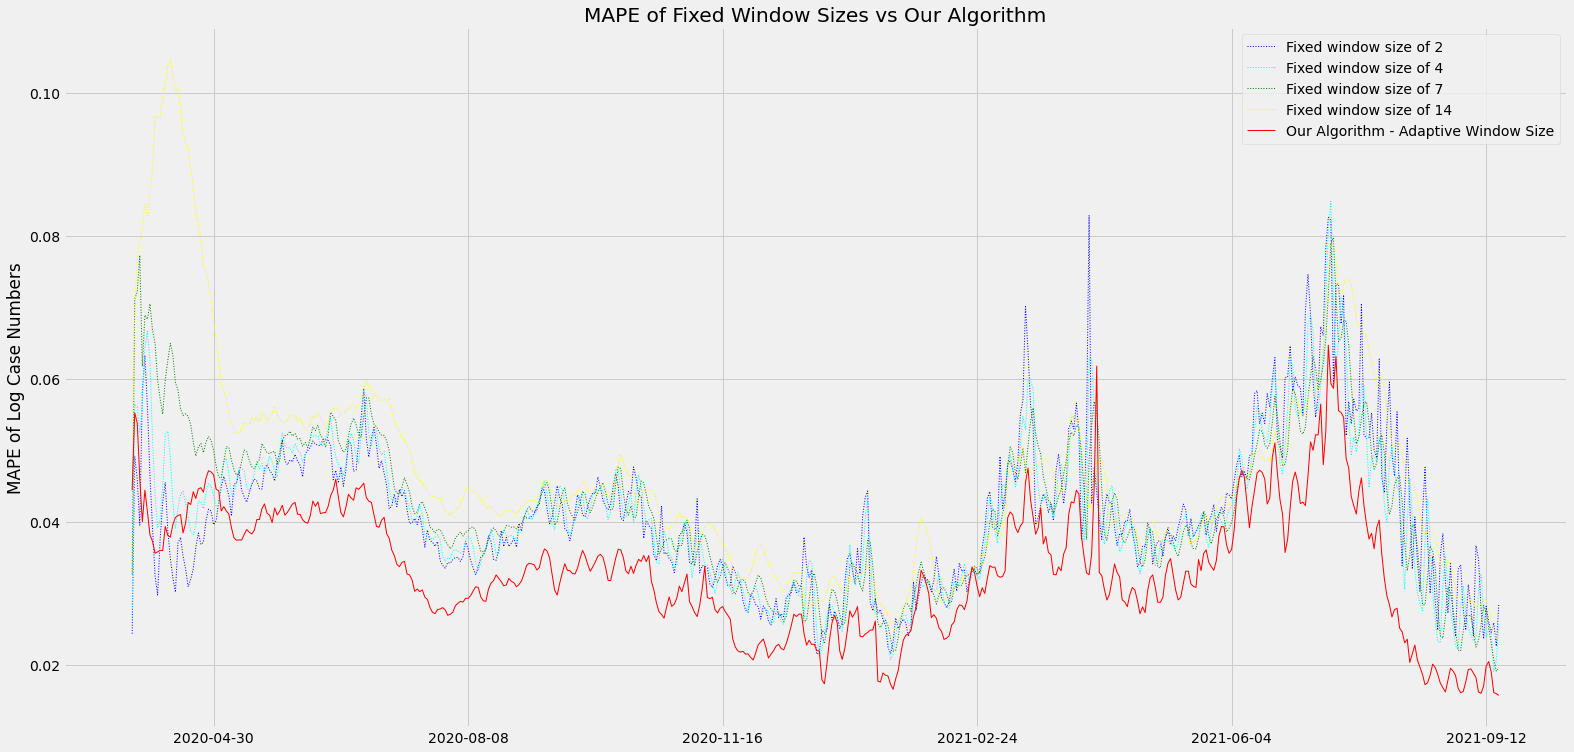

In [32]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
wsizes = [2,4,7,14]
colors_lm = ["blue", "cyan", "green", "yellow"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["Our Algorithm - Adaptive Window Size"]
for i,wsize in enumerate(wsizes):
    ax.plot(error_table["lm.mape.{}".format(wsize)], linestyle='dotted', linewidth=1, color=colors_lm[i], label=my_legend[i])
ax.plot(error_table["grf.mape"], label=my_legend[-1], linewidth=1, color="red")
ax.legend()

#plt.ylim([0.1,0.4])
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])


plt.ylabel("MAPE of Log Case Numbers")
plt.title("MAPE of Fixed Window Sizes vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_mape.png"))

In [33]:
mape_medians = {}
mape_medians["grf"] = error_table["grf.mape"].median()
for i,wsize in enumerate(wsizes):
    mape_medians["{}".format(wsize)] = error_table["lm.mape.{}".format(wsize)].median()
mape_medians

{'grf': 0.032791035244132787,
 '2': 0.040057421865668116,
 '4': 0.0403602782455694,
 '7': 0.04115417812816183,
 '14': 0.04358374511773528}

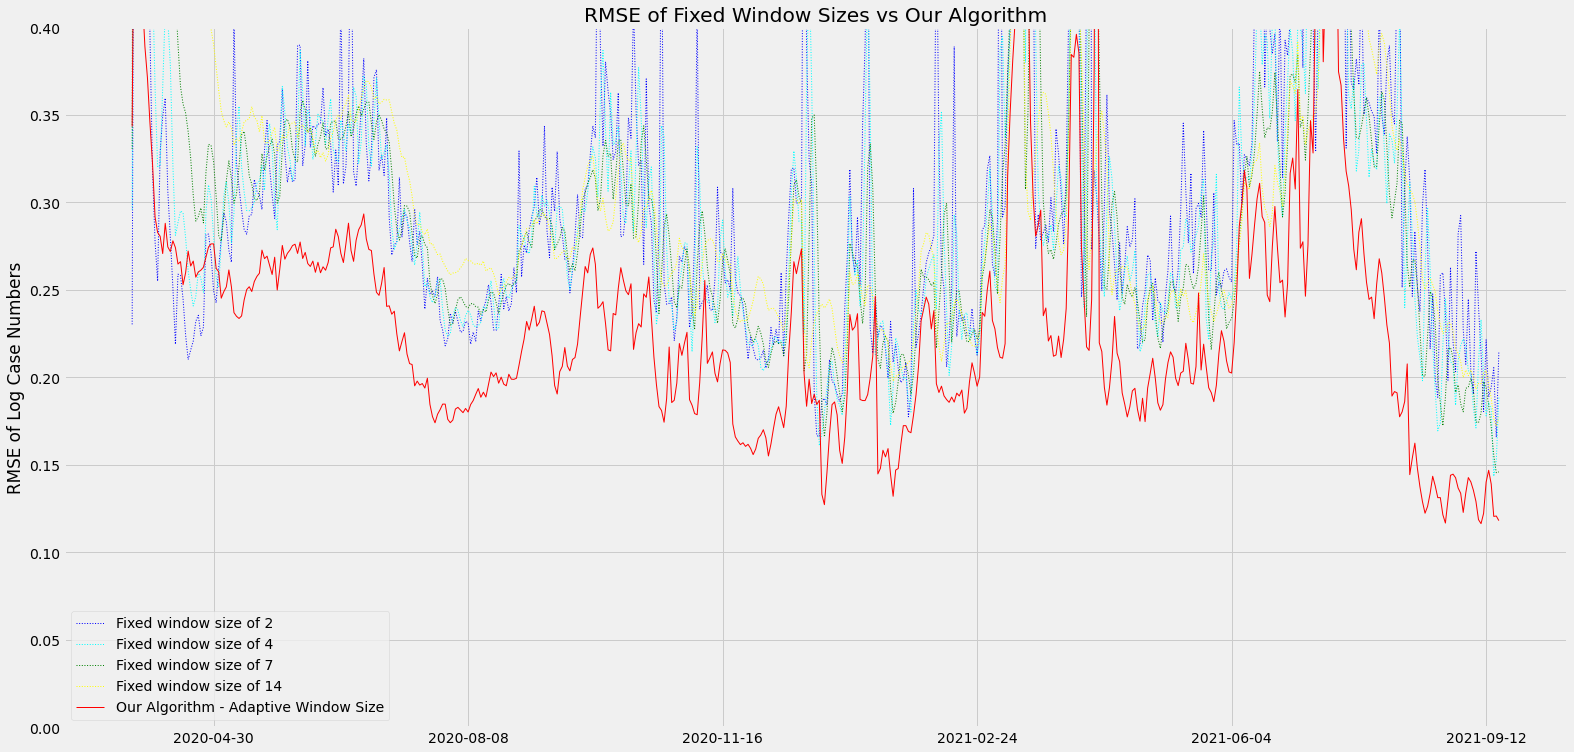

In [34]:
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
colors_lm = ["blue", "cyan", "green", "yellow"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["Our Algorithm - Adaptive Window Size"]

for i,wsize in enumerate([2,4,7,14]):
    #print((i,wsize,colors_lm[i]))
    ax.plot(error_table["lm.rmse.{}".format(wsize)], linestyle='dotted', linewidth=1, color=colors_lm[i], label=my_legend[i])
ax.plot(error_table["grf.rmse"], label=my_legend[-1], color="red", linewidth=1)


leg = plt.legend()
plt.ylim([0.0,0.4])


#plt.setp(leg.get_lines(),linewidth=1)

plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])

plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of Fixed Window Sizes vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_rmse.png"))

In [35]:
rmse_medians = {}
rmse_medians["TLGRF"] = error_table["grf.rmse"].median()
rmse_medians["GRF"] = error_table["grf.HTE.rmse"].median()

for i,wsize in enumerate(wsizes):
    rmse_medians["{}".format(wsize)] = error_table["lm.rmse.{}".format(wsize)].median()
rmse_medians

{'TLGRF': 0.21942062810012752,
 'GRF': 0.3103495675534567,
 '2': 0.2823240299061274,
 '4': 0.2844059556939138,
 '7': 0.2822813298360959,
 '14': 0.28096668600965324}

### Best Fixed Window Sizes for Each County 

In [36]:
fips_rmse_fname = os.path.join(DATA_FOLDER,"fips_rmse.p")
fips_mape_fname = os.path.join(DATA_FOLDER,"fips_mape.p")

if not (os.path.isfile(fips_rmse_fname) and  os.path.isfile(fips_mape_fname) ) or OVERWRITE:

    fips_rmse = {}
    fips_mape = {}
    for fips in tqdm(adjusted["fips"].unique()):
        df = adjusted[adjusted["fips"]==fips]
        best_rmse = np.inf
        best_mape = np.inf
        best_rmse_wsize = -999
        best_mape_wsize = -999
        for wsize in range(2,14+1):
            current_rmse = mean_squared_error(df["lm.pred.{}".format(wsize)], df["log_rolled_cases"]) ** .5
            if current_rmse < best_rmse:
                best_rmse = current_rmse
                best_rmse_wsize = wsize

            current_mape = mean_absolute_error(df["lm.pred.{}".format(wsize)], df["log_rolled_cases"])
            if current_mape < best_mape:
                best_mape = current_mape
                best_mape_wsize = wsize
        fips_mape[fips] = best_mape_wsize
        fips_rmse[fips] = best_rmse_wsize
    with open(fips_rmse_fname, "wb+") as f:
        pickle.dump(fips_rmse,f)
    with open(fips_mape_fname, "wb+") as f:
        pickle.dump(fips_mape,f)
else:
    with open(fips_rmse_fname, "rb+") as f:
        fips_rmse = pickle.load(f)
    with open(fips_mape_fname, "rb+") as f:
        fips_mape = pickle.load(f) 

In [37]:
# Compile Error Table using Best fixed window sizes of each fips
# Build new Dataframe
error_expost_fname = os.path.join(DATA_FOLDER,"error_expost.csv")
if (not os.path.isfile(error_expost_fname) or OVERWRITE):
    error_expost = pd.DataFrame()
    for fips in tqdm(adjusted["fips"].unique()):
        df_mask = (adjusted["fips"] == fips)
        df = adjusted[df_mask]
        new_df = df[["date","fips", "days_from_start","log_rolled_cases"]]
        new_df["lm.pred.mape.best"] = df["lm.pred.{}".format(fips_mape[fips])].values
        new_df["lm.pred.rmse.best"] = df["lm.pred.{}".format(fips_rmse[fips])].values
        error_expost = pd.concat([error_expost, new_df])
    error_expost.to_csv(error_expost_fname)
    #error_expost = error_expost.set_index(sorted(adjusted["days_from_start.y"].unique()))
else:
    error_expost = pd.read_csv(error_expost_fname)

In [38]:
# Generate by Day
error_expost_by_day = pd.DataFrame()

error_expost_by_day["lm.rmse"]=error_expost.groupby(["days_from_start"]).apply(lambda x: mean_squared_error(x["lm.pred.rmse.best"], x["log_rolled_cases"]) ** .5)
error_expost_by_day["lm.mape"]=error_expost.groupby(["days_from_start"]).apply(lambda x: mean_absolute_percentage_error( x["log_rolled_cases"], x["lm.pred.mape.best"]) )
error_expost_by_day["lm.mae"]=error_expost.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error(x["lm.pred.mape.best"], x["log_rolled_cases"]) )

error_expost_by_day["grf.mape"] = error_table["grf.mape"]
error_expost_by_day["grf.mae"] = error_table["grf.mae"]
error_expost_by_day["grf.rmse"] = error_table["grf.rmse"]
error_expost_by_day["date.y"] = error_table["date"]
error_expost_by_day.to_csv(os.path.join(DATA_FOLDER,"error_expost_by_day.csv"))

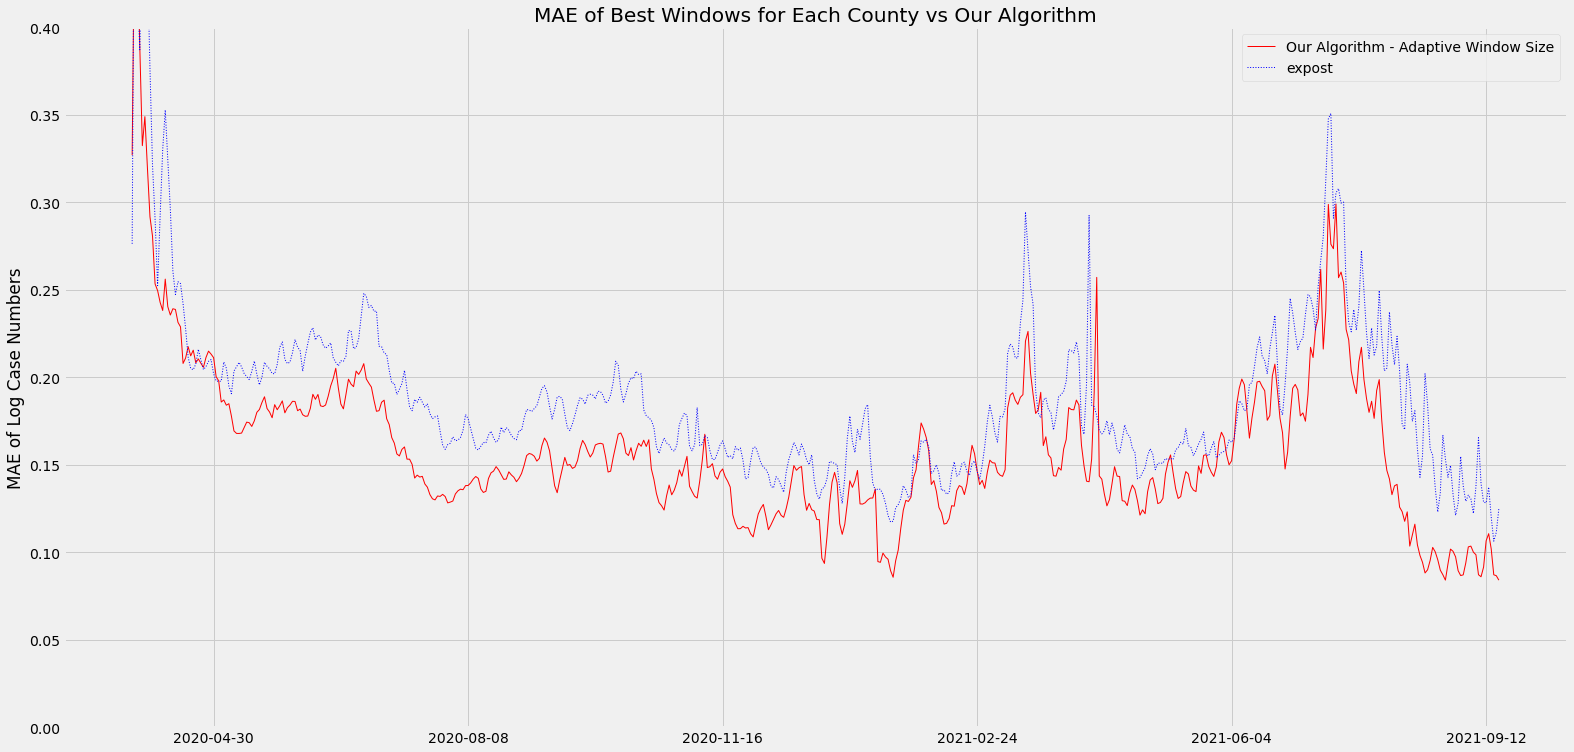

In [39]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
my_legend = ["expost","Our Algorithm - Adaptive Window Size"]
ax.plot(error_expost_by_day["grf.mae"], linewidth=1, label=my_legend[1], color="red")
ax.plot(error_expost_by_day["lm.mae"], linewidth=1, linestyle='dotted', label=my_legend[0], color="blue")
ax.legend()
plt.xticks(x_spacing,error_expost_by_day["date.y"][x_spacing])
plt.ylim([0.0,0.4])
plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Best Windows for Each County vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"best_windows_mae.png"))

In [40]:
expost_mae_medians = {}
expost_mae_medians["grf"] = error_expost_by_day["grf.mae"].median()
expost_mae_medians["lm"] = error_expost_by_day["lm.mae"].median()
expost_mae_medians

{'grf': 0.1491243347961326, 'lm': 0.17812858422720748}

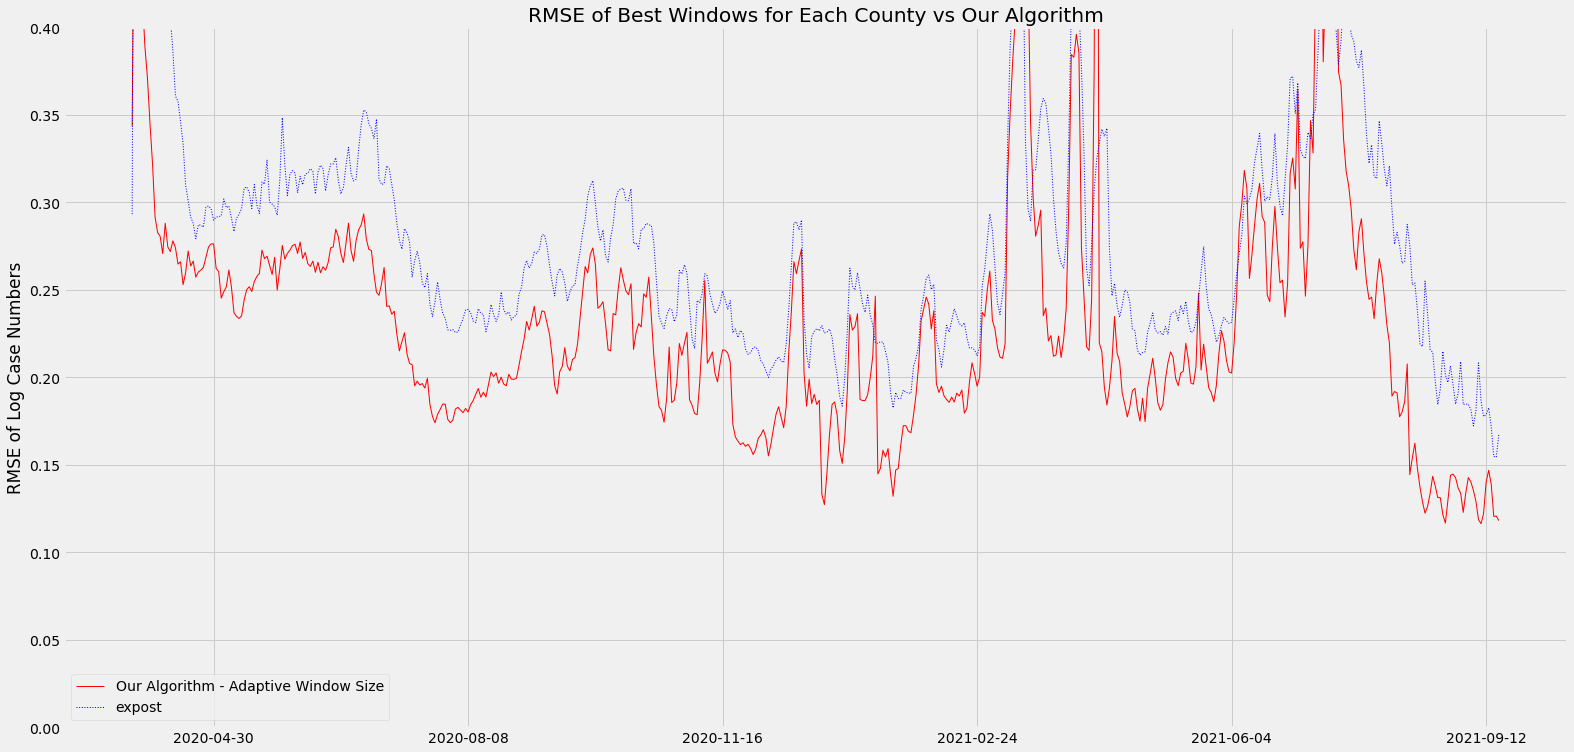

In [41]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
my_legend = ["expost","Our Algorithm - Adaptive Window Size"]

ax.plot(error_expost_by_day["grf.rmse"],linewidth=1, label=my_legend[1], color="red")
ax.plot(error_expost_by_day["lm.rmse"],linewidth=1, linestyle='dotted', label=my_legend[0], color="blue")
ax.legend()
plt.xticks(x_spacing,error_expost_by_day["date.y"][x_spacing])
plt.ylim([0.0,0.4])
plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of Best Windows for Each County vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"best_windows_rmse.png"))

In [42]:
expost_rmse_medians = {}
expost_rmse_medians["grf"] = error_expost_by_day["grf.rmse"].median()
expost_rmse_medians["lm"] = error_expost_by_day["lm.rmse"].median()
expost_rmse_medians

{'grf': 0.21942062810012752, 'lm': 0.26331677273719944}

### limsup of windows per time chosen via cross validation

In [43]:
class GroupTimeSeriesSplit(_BaseKFold):
    """
    Time Series cross-validator for a variable number of observations within the time 
    unit. In the kth split, it returns first k folds as train set and the (k+1)th fold 
    as test set. Indices can be grouped so that they enter the CV fold together.

    Parameters
    ----------
    n_splits : int, default=5
        Number of splits. Must be at least 2.
    max_train_size : int, default=None
        Maximum size for a single training set.
    """
    def __init__(self, n_splits=5, *, max_train_size=None):
        super().__init__(n_splits, shuffle=False, random_state=None)
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        """
        Generate indices to split data into training and test set.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data, where n_samples is the number of samples and n_features is 
            the number of features.
        y : array-like of shape (n_samples,)
            Always ignored, exists for compatibility.
        groups : array-like of shape (n_samples,)
            Group labels for the samples used while splitting the dataset into 
            train/test set.
            Most often just a time feature.

        Yields
        -------
        train : ndarray
            The training set indices for that split.
        test : ndarray
            The testing set indices for that split.
        """
        n_splits = self.n_splits
        X, y, groups = indexable(X, y, groups)
        n_samples = _num_samples(X)
        n_folds = n_splits + 1
        indices = np.arange(n_samples)
        group_counts = np.unique(groups, return_counts=True)[1]
        groups = np.split(indices, np.cumsum(group_counts)[:-1])
        n_groups = _num_samples(groups)
        if n_folds > n_groups:
            raise ValueError(
                ("Cannot have number of folds ={0} greater"
                 " than the number of groups: {1}.").format(n_folds, n_groups))
        test_size = (n_groups // n_folds)
        test_starts = range(test_size + n_groups % n_folds,
                            n_groups, test_size)
        for test_start in test_starts:
            if self.max_train_size:
                train_start = np.searchsorted(
                    np.cumsum(
                        group_counts[:test_start][::-1])[::-1] < self.max_train_size + 1, 
                        True)
                yield (np.concatenate(groups[train_start:test_start]),
                       np.concatenate(groups[test_start:test_start + test_size]))
            else:
                yield (np.concatenate(groups[:test_start]),
                       np.concatenate(groups[test_start:test_start + test_size]))


In [44]:
user = np.repeat(np.arange(10), 12)
time = np.tile(pd.date_range(start='2018-01-01', periods=12, freq='M'), 10)
data = (pd.DataFrame({'user': user, 'time': time})
        .sort_values(['time', 'user'])
        .reset_index(drop=True))

In [45]:
ts_data = adjusted[["fips","days_from_start","log_rolled_cases"]].sort_values(["days_from_start","fips"]).reset_index(drop=True)

gtscv = GroupTimeSeriesSplit(n_splits=len(ts_data["days_from_start"].unique())//8+1)
gtscv_gen = gtscv.split(ts_data, groups=ts_data["days_from_start"])
for split_id, (train_id, val_id) in enumerate(gtscv_gen):
    print("Split id: ", split_id, "\n") 
    print("Train id: ", train_id, "\n", "Validation id: ", val_id)
    print("Train dates: ", ts_data.loc[train_id, "days_from_start"].unique(), "\n", "Validation dates: ", ts_data.loc[val_id, "days_from_start"].unique(), "\n")


Split id:  0 

Train id:  [    0     1     2 ... 39157 39158 39159] 
 Validation id:  [39160 39161 39162 ... 46875 46876 46877]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129] 
 Validation dates:  [130 131 132 133 134 135 136] 

Split id:  1 

Train id:  [    0     1     2 ... 46875 46876 46877] 
 Validation id:  [46878 46879 46880 ... 54862 54863 54864]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136] 
 Validation dates:  [137 138 139 140 141 142 143] 

Split id:  2 

Train id:  [    0     1     2 ... 54862 54863 54864] 
 Valida

Split id:  21 

Train id:  [     0      1      2 ... 314011 314012 314013] 
 Validation id:  [314014 314015 314016 ... 332376 332377 332378]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265
 266 267 268 269 270 271 272 273 274 275 2

Split id:  31 

Train id:  [     0      1      2 ... 514888 514889 514890] 
 Validation id:  [514891 514892 514893 ... 535701 535702 535703]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265
 266 267 268 269 270 271 272 273 274 275 2

 Validation dates:  [382 383 384 385 386 387 388] 

Split id:  37 

Train id:  [     0      1      2 ... 637729 637730 637731] 
 Validation id:  [637732 637733 637734 ... 657194 657195 657196]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 26

 Validation dates:  [424 425 426 427 428 429 430] 

Split id:  43 

Train id:  [     0      1      2 ... 746386 746387 746388] 
 Validation id:  [746389 746390 746391 ... 762683 762684 762685]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 26

 Validation dates:  [466 467 468 469 470 471 472] 

Split id:  49 

Train id:  [     0      1      2 ... 840385 840386 840387] 
 Validation id:  [840388 840389 840390 ... 855616 855617 855618]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 26

Split id:  55 

Train id:  [     0      1      2 ... 923809 923810 923811] 
 Validation id:  [923812 923813 923814 ... 934351 934352 934353]
Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265
 266 267 268 269 270 271 272 273 274 275 2

Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265
 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283
 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301
 302 303 304 305 306 307 308 309 310 

Train dates:  [ 68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265
 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283
 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301
 302 303 304 305 306 307 308 309 310 

In [46]:
# TCV: For each time, choose lowest average mae across all counties
tcv_rmse = np.zeros(len(adjusted["days_from_start"].unique())-1)
tcv_mae = np.zeros(len(adjusted["days_from_start"].unique())-1)   
tcv_mape = np.zeros(len(adjusted["days_from_start"].unique())-1)                  

counter = 0
for day in sorted(adjusted["days_from_start"].unique())[:-1]:
    day_df = adjusted[adjusted["days_from_start"]==day]
    rmse = np.inf
    mae = np.inf
    mape = np.inf
    rmse_index = 2
    mae_index = 2
    mape_index = 2
    for wsize in range(2,15):
        #rmse = min(rmse,np.sqrt( mean_squared_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )))
        #mae = min(mae,(mean_absolute_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )))
        if rmse > np.sqrt( mean_squared_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )):
            rmse = np.sqrt( mean_squared_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] ))
            rmse_index = wsize
        if mae >  mean_absolute_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] ):
            mae =  mean_absolute_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )
            mae_index = wsize
        if mape >  mean_absolute_percentage_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] ):
            mape =  mean_absolute_percentage_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )
            mape_index = wsize
    day_df_future = adjusted[adjusted["days_from_start"]==day+1]
    
    rmse_future = np.sqrt( mean_squared_error( day_df_future['log_rolled_cases'], day_df_future['lm.pred.{}'.format(rmse_index)] ))
    mae_future = mean_absolute_error( day_df_future['log_rolled_cases'], day_df_future['lm.pred.{}'.format(mae_index)] )
    mape_future = mean_absolute_percentage_error( day_df_future['log_rolled_cases'], day_df_future['lm.pred.{}'.format(mape_index)] )

    tcv_rmse[counter] = rmse_future
    tcv_mae[counter] = mae_future
    tcv_mape[counter] = mape_future
    counter += 1
                   

In [47]:
tcv_mae = pd.DataFrame(tcv_mae)
tcv_mae.index = sorted(adjusted["days_from_start"].unique())[1:]
tcv_rmse = pd.DataFrame(tcv_rmse)
tcv_rmse.index = sorted(adjusted["days_from_start"].unique())[1:]
tcv_mape = pd.DataFrame(tcv_mape)
tcv_mape.index = sorted(adjusted["days_from_start"].unique())[1:]


In [48]:
tcv_mae

,0
69,0.462440
70,0.402215
71,0.344680
72,0.458895
73,0.499834
...,...
601,0.134187
602,0.123741
603,0.111039
604,0.112561


In [49]:
#error_table[mape_columns]
#error_table[rmse_columns]
lm_mape_columns = ["lm.mape.{}".format(wsize) for wsize in range(2,14+1)]
lm_rmse_columns = ["lm.rmse.{}".format(wsize) for wsize in range(2,14+1)]

limsup_mape = error_table[lm_mape_columns].max(axis=1)
limsup_rmse = error_table[lm_rmse_columns].max(axis=1)

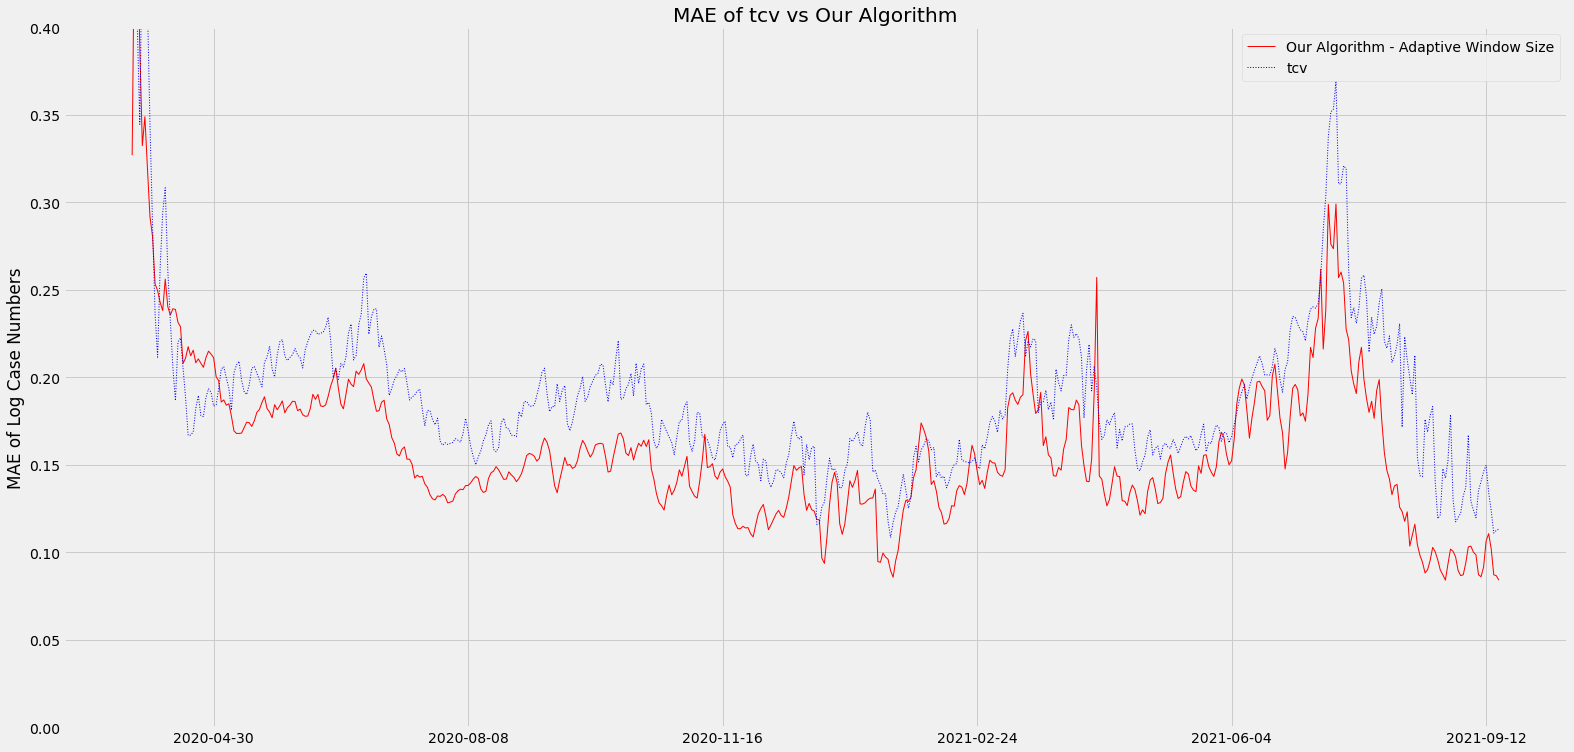

In [50]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.mae"], label="Our Algorithm - Adaptive Window Size", color="red", linewidth=1)
ax.plot(tcv_mae, label="tcv", color="blue", linestyle='dotted', linewidth=1)
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.0,0.4])
plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of tcv vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"limsup_mae.png"))

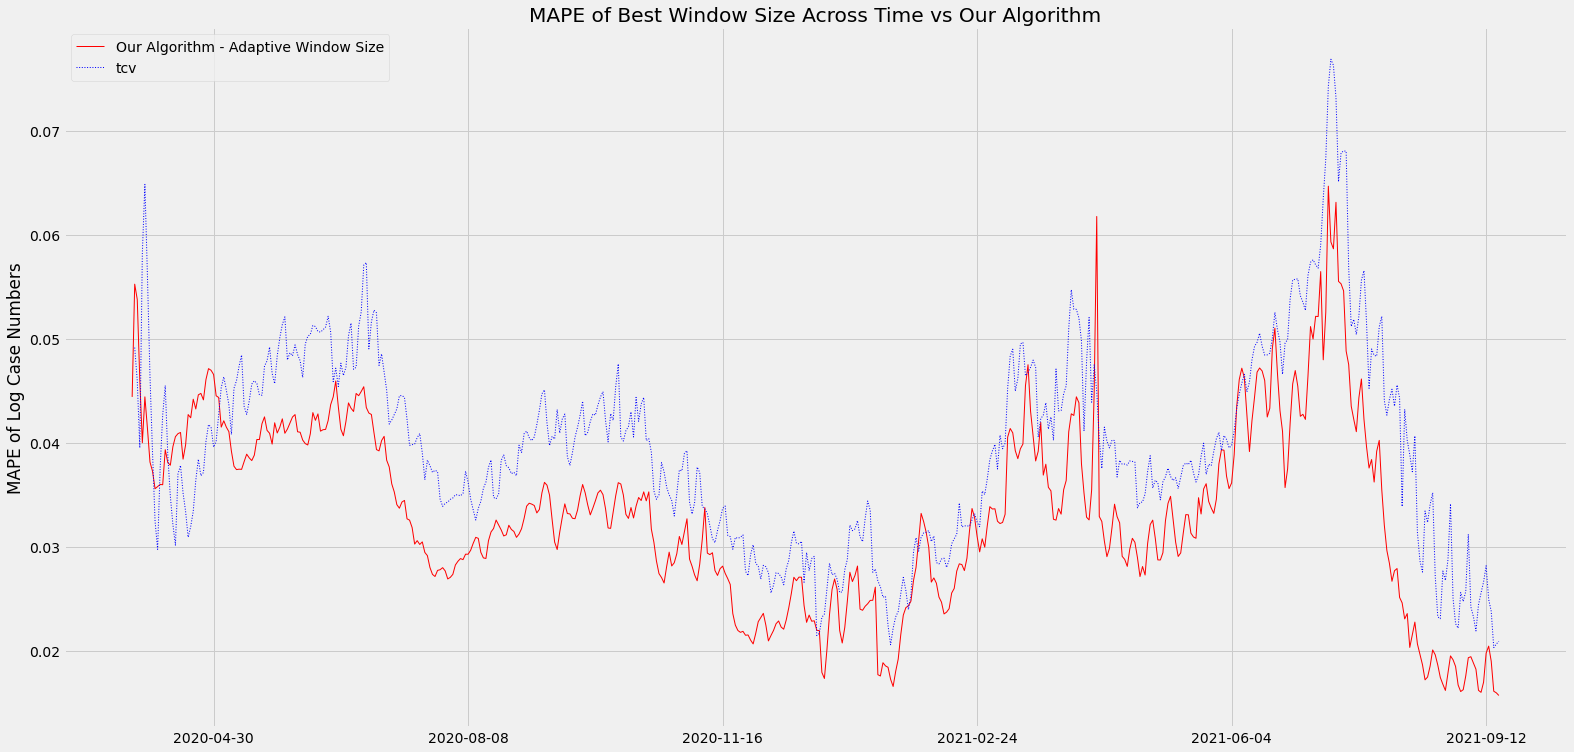

In [51]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.mape"], label="Our Algorithm - Adaptive Window Size", color="red", linewidth=1)
ax.plot(tcv_mape, label="tcv", color="blue", linestyle='dotted', linewidth=1)
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.ylim([0.1,0.4])
plt.ylabel("MAPE of Log Case Numbers")
plt.title("MAPE of Best Window Size Across Time vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"limsup_mape.png"))

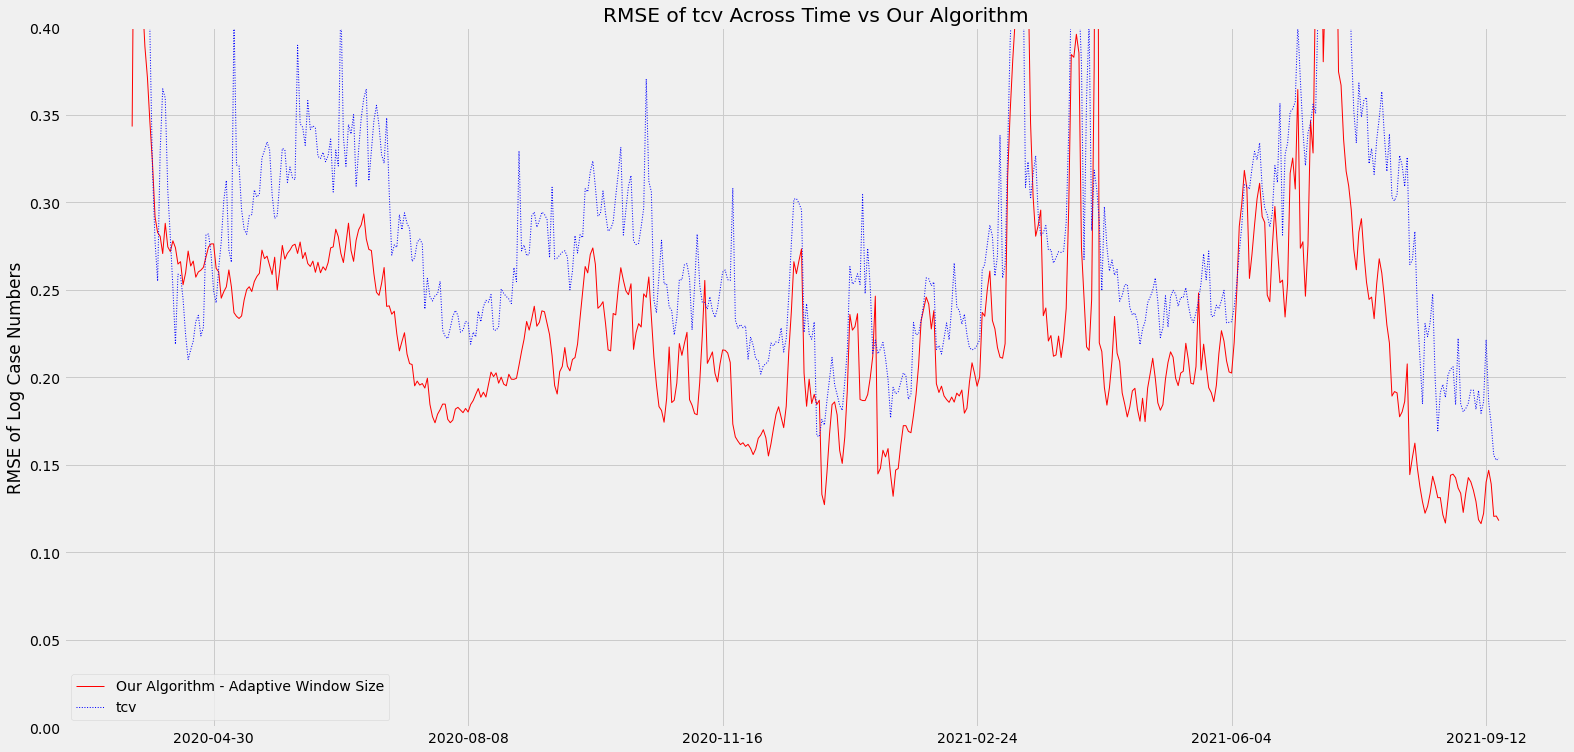

In [52]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.rmse"], label="Our Algorithm - Adaptive Window Size", color="red", linewidth=1)
ax.plot(tcv_rmse, label="tcv", color="blue", linestyle='dotted', linewidth=1)
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.0,0.4])
plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of tcv Across Time vs Our Algorithm")
#plt.xlim([365,len(grf_rmse)])
plt.savefig(os.path.join(FIGURES_FOLDER,"limsup_rmse.png"))

In [53]:
tcv_mae_medians = {}
tcv_mae_medians["grf"] = error_expost_by_day["grf.mae"].median()
tcv_mae_medians["lm"] = tcv_mae.median()
tcv_mae_medians

{'grf': 0.1491243347961326,
 'lm': 0    0.179815
 dtype: float64}

In [54]:
tcv_mape_medians = {}
tcv_mape_medians["grf"] = error_expost_by_day["grf.mape"].median()
tcv_mape_medians["lm"] = tcv_mape.median()
tcv_mape_medians

{'grf': 0.032791035244132787,
 'lm': 0    0.039113
 dtype: float64}

In [55]:
tcv_rmse_medians = {}
tcv_rmse_medians["grf"] = error_expost_by_day["grf.rmse"].median()
tcv_rmse_medians["lm"] = tcv_rmse.median()
tcv_rmse_medians

{'grf': 0.21942062810012752,
 'lm': 0    0.267356
 dtype: float64}

### liminf of windows per time chosen via cross validation

In [56]:
#error_table[mape_columns]
#error_table[rmse_columns]
lm_mape_columns = ["lm.mape.{}".format(wsize) for wsize in range(2,14+1)]
lm_mae_columns = ["lm.mae.{}".format(wsize) for wsize in range(2,14+1)]
lm_rmse_columns = ["lm.rmse.{}".format(wsize) for wsize in range(2,14+1)]

liminf_mae = error_table[lm_mae_columns].min(axis=1)
liminf_mape = error_table[lm_mape_columns].min(axis=1)
liminf_rmse = error_table[lm_rmse_columns].min(axis=1)

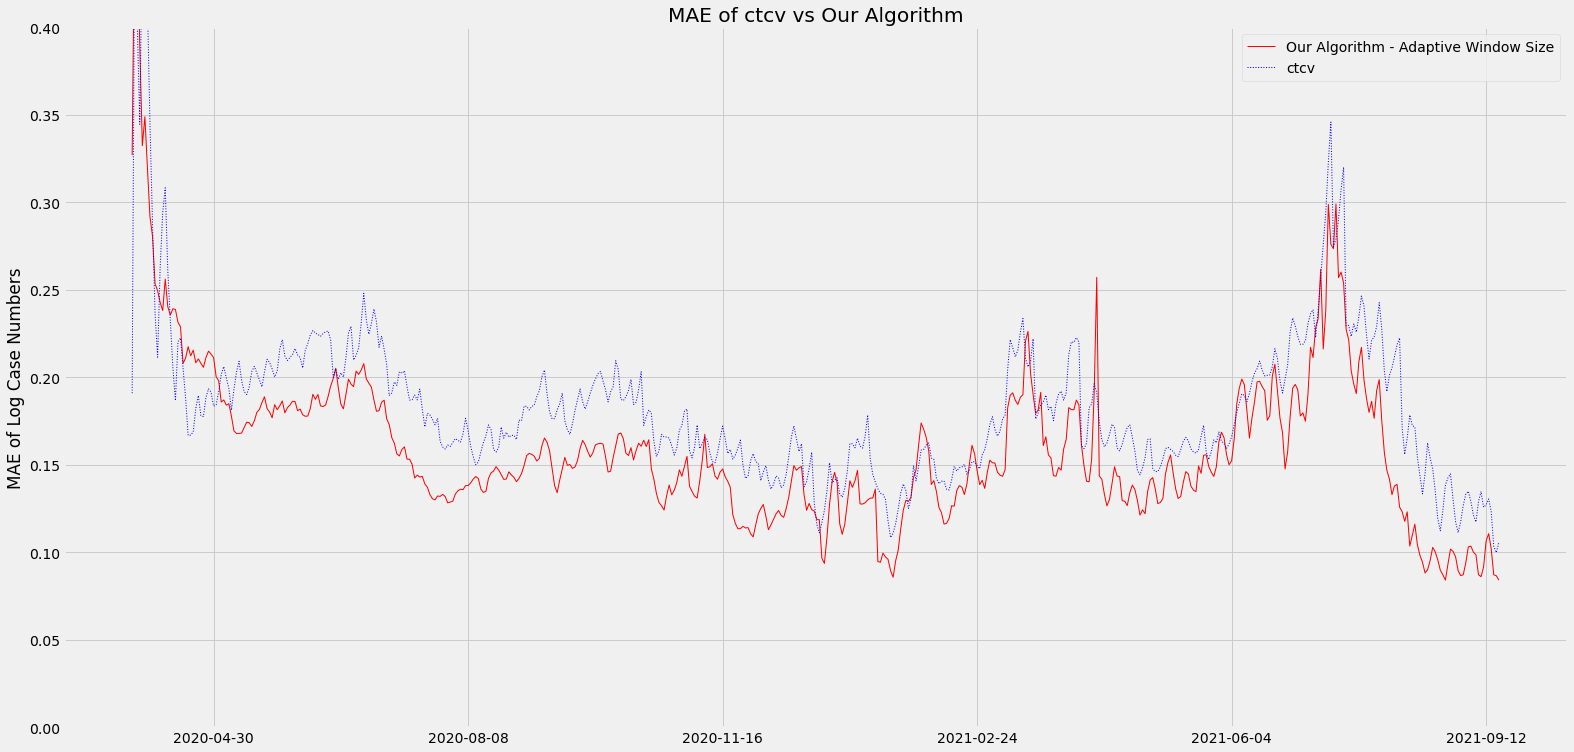

In [57]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.mae"], linewidth=1, label="Our Algorithm - Adaptive Window Size", color="red")
ax.plot(liminf_mae, label="ctcv", linewidth=1, linestyle="dotted", color="blue")
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.0,0.4])
plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of ctcv vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"liminf_mae.png"))

In [58]:
ctcv_mae_medians = {}
ctcv_mae_medians["grf"] = error_expost_by_day["grf.mae"].median()
ctcv_mae_medians["lm"] = liminf_mae.median()
ctcv_mae_medians

{'grf': 0.1491243347961326, 'lm': 0.1752630093890756}

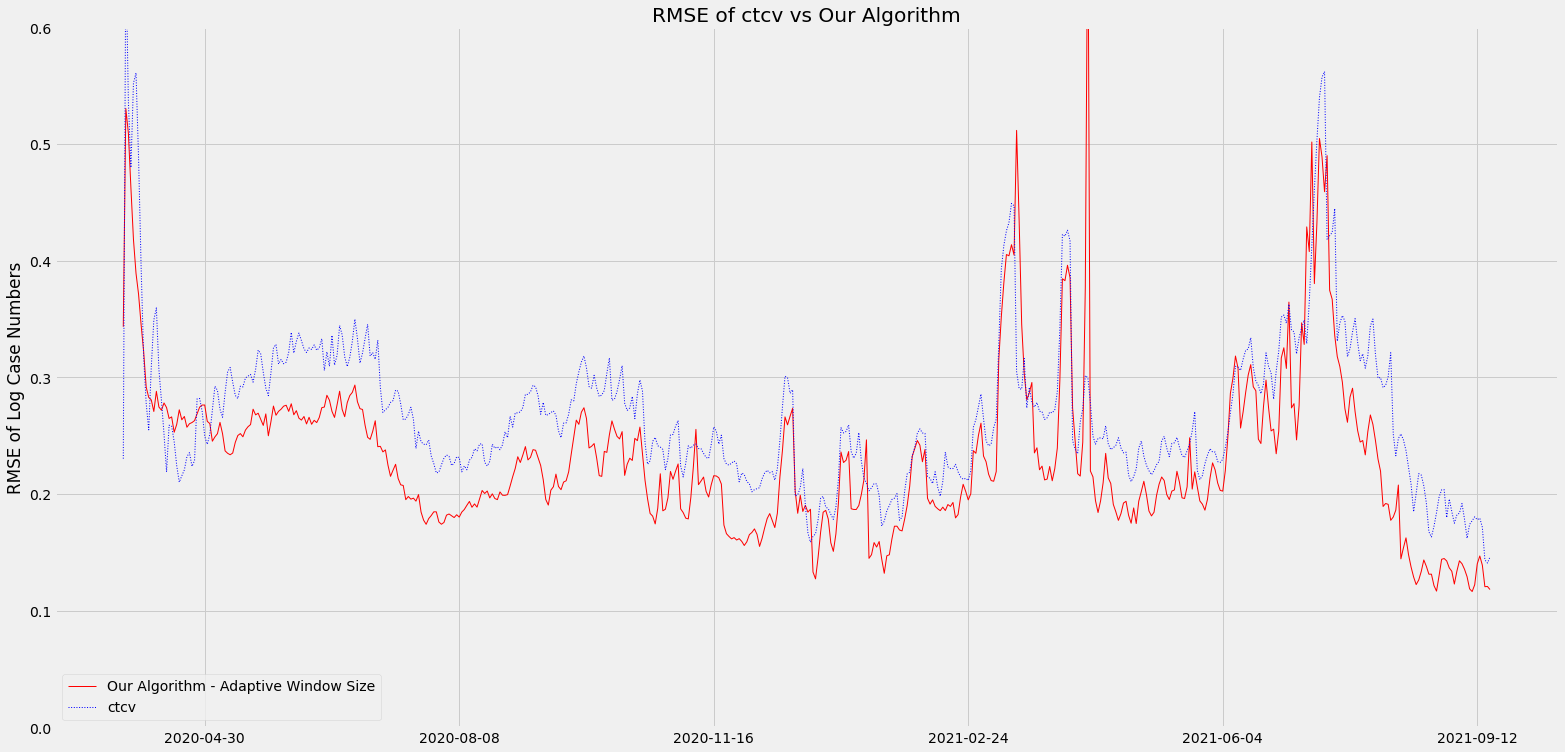

In [59]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.rmse"], linewidth=1, label="Our Algorithm - Adaptive Window Size", color="red")
ax.plot(liminf_rmse, label="ctcv", linewidth=1, linestyle="dotted", color="blue")
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.0,0.6])
plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of ctcv vs Our Algorithm")
#plt.xlim([365,len(grf_rmse)])
plt.savefig(os.path.join(FIGURES_FOLDER,"liminf_rmse.png"))

In [60]:
ctcv_rmse_medians = {}
ctcv_rmse_medians["grf"] = error_expost_by_day["grf.rmse"].median()
ctcv_rmse_medians["lm"] = liminf_rmse.median()
ctcv_rmse_medians

{'grf': 0.21942062810012752, 'lm': 0.2546080072794248}

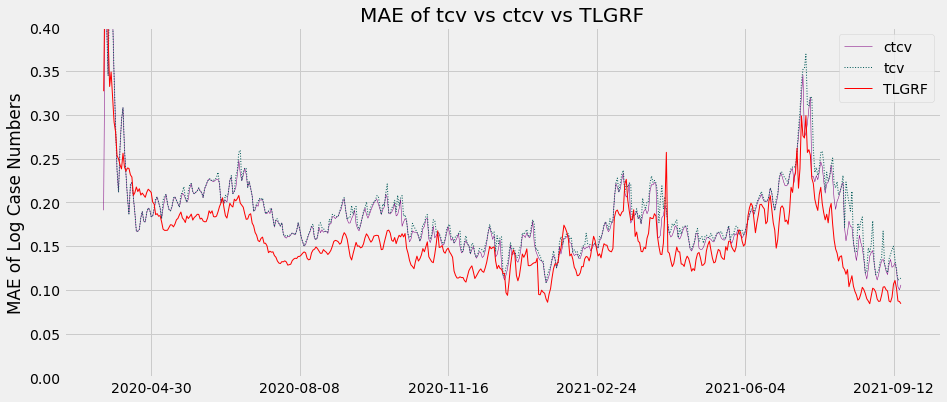

In [61]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(14, 6))
#for wsize in range(2,14+1,2):
ax.plot(liminf_mae, label="ctcv", linewidth=0.5, color="purple")
ax.plot(tcv_mae, label="tcv", color="xkcd:dark turquoise", linestyle=':', linewidth=1)
ax.plot(error_table["grf.mae"], linewidth=1, label="TLGRF", color="red")

ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.0,0.4])
plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of tcv vs ctcv vs TLGRF")
plt.savefig(os.path.join(FIGURES_FOLDER,"tcv_ctcv_mae.png"))

In [62]:
dict(sorted(collections.Counter(fips_rmse.values()).items(), key=lambda e:e[0]))

{2: 723,
 3: 585,
 4: 99,
 5: 38,
 6: 119,
 7: 192,
 8: 233,
 9: 201,
 10: 132,
 11: 80,
 12: 67,
 13: 89,
 14: 542}

In [63]:
adjusted

,fips,days_from_start,predicted.grf,date,county,state,log_rolled_cases,lm.pred.2,lm.pred.3,lm.pred.4,lm.pred.5,lm.pred.6,lm.pred.7,lm.pred.8,lm.pred.9,lm.pred.10,lm.pred.11,lm.pred.12,lm.pred.13,lm.pred.14,predicted.grf.HTE,predicted.grf.HTE_2BLOCK
10,10001,88,6.186006,2020-04-18,Kent,Delaware,5.881929,6.274697,6.305973,6.460198,6.657827,6.779492,6.894292,6.933171,6.933535,6.915480,6.879093,6.837612,6.794018,6.743927,6.505592,6.591270
11,10001,89,6.224368,2020-04-19,Kent,Delaware,5.920908,6.051755,6.203723,6.283276,6.420656,6.596258,6.723148,6.842956,6.900525,6.921485,6.921946,6.902623,6.875277,6.843273,6.460537,6.472518
12,10001,90,6.131221,2020-04-20,Kent,Delaware,5.964864,6.061046,6.092416,6.196145,6.275717,6.396586,6.552313,6.676777,6.796304,6.864985,6.900380,6.915099,6.909804,6.894752,6.462694,6.505425
13,10001,91,6.202979,2020-04-21,Kent,Delaware,6.006969,6.251632,6.199764,6.197839,6.260801,6.323979,6.424278,6.558545,6.674240,6.788287,6.861333,6.905206,6.929540,6.934606,6.521824,6.517018
14,10001,92,6.114442,2020-04-22,Kent,Delaware,6.050912,6.217303,6.270319,6.260405,6.262809,6.309705,6.362789,6.448108,6.565097,6.671602,6.779032,6.853294,6.902291,6.933330,6.538333,6.606417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474311,99999,601,10.642014,2021-09-13,New York City,New York,10.557114,10.552786,10.503129,10.484691,10.504834,10.534865,10.564571,10.586209,10.599192,10.606162,10.613438,10.620428,10.626583,10.631276,10.519448,10.468994
1474312,99999,602,10.595805,2021-09-14,New York City,New York,10.551304,10.500115,10.518746,10.496403,10.481217,10.492194,10.514025,10.538337,10.557812,10.570795,10.578768,10.586769,10.594369,10.601123,10.498929,10.507343
1474313,99999,603,10.538255,2021-09-15,New York City,New York,10.535902,10.511698,10.499888,10.506343,10.491571,10.478665,10.484527,10.500536,10.520276,10.537306,10.549537,10.557702,10.565850,10.573621,10.546842,10.517822
1474314,99999,604,10.555976,2021-09-16,New York City,New York,10.546380,10.493169,10.496010,10.490061,10.493357,10.482845,10.472136,10.475291,10.487376,10.503584,10.518416,10.529695,10.537693,10.545709,10.550062,10.522120


In [64]:
class WindowedTestTimeSeriesSplit(TimeSeriesSplit):
    """
    parameters
    ----------
    n_test_folds: int
        number of folds to be used as testing at each iteration.
        by default, 1.
    """
    @_deprecate_positional_args
    def __init__(self, n_splits=5, *, max_train_size=None, n_test_folds=1):
        super().__init__(n_splits, 
                         max_train_size=max_train_size)
        self.n_test_folds=n_test_folds

    def split(self, X, y=None, groups=None):
        """Generate indices to split data into training and test set.
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data, where n_samples is the number of samples
            and n_features is the number of features.
        y : array-like of shape (n_samples,)
            Always ignored, exists for compatibility.
        groups : array-like of shape (n_samples,)
            Always ignored, exists for compatibility.
        Yields
        ------
        train : ndarray
            The training set indices for that split.
        test : ndarray
            The testing set indices for that split.
        """
        X, y, groups = indexable(X, y, groups)
        n_samples = _num_samples(X)
        n_splits = self.n_splits
        n_folds = n_splits + self.n_test_folds
        if n_folds > n_samples:
            raise ValueError(
                ("Cannot have number of folds ={0} greater"
                 " than the number of samples: {1}.").format(n_folds,
                                                             n_samples))
        indices = np.arange(n_samples)
        fold_size = (n_samples // n_folds)
        test_size = fold_size * self.n_test_folds # test window
        test_starts = range(fold_size + n_samples % n_folds,
                            n_samples-test_size+1, fold_size) # splits based on fold_size instead of test_size
        for test_start in test_starts:
            if self.max_train_size and self.max_train_size < test_start:
                yield (indices[test_start - self.max_train_size:test_start],
                       indices[test_start:test_start + test_size])
            else:
                yield (indices[:test_start],
                       indices[test_start:test_start + test_size])
